# Image_to_Sketch
Parsa Darban 810100141

# Library

In [29]:
import cv2
import os
import matplotlib.pyplot as plt
import time
import sys
import os
import numpy as np

# Load & Display Image

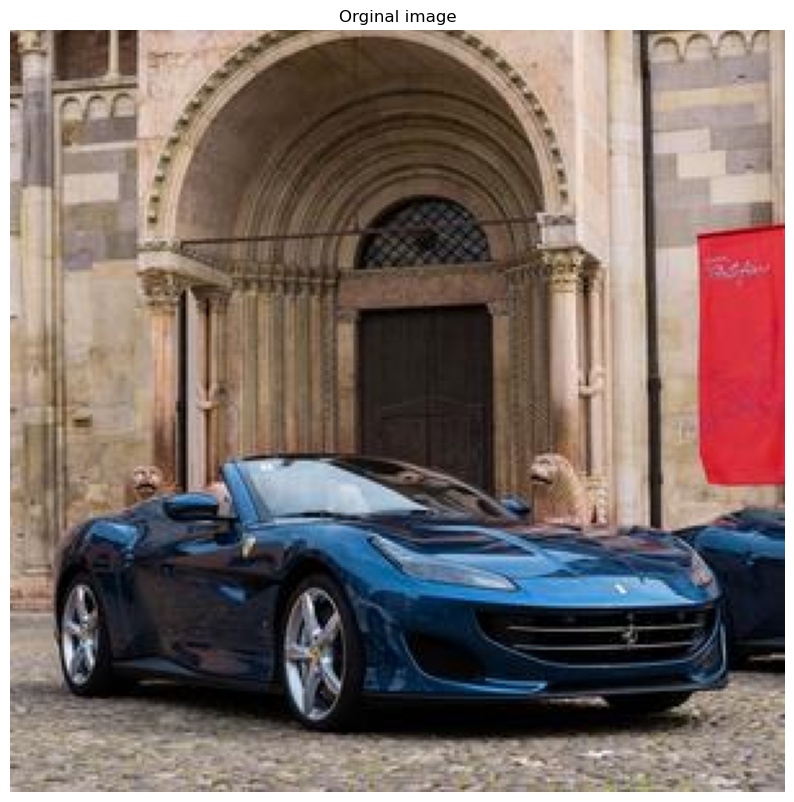

In [31]:
image_address = os.path.join("images", "car.jpg")

image = cv2.imread(image_address) 
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Orginal image")
plt.axis("off")
plt.show()

# Sketch

In [40]:
def sketch_image (image):

    image = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
    
    gray_image = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY)
    inverted_image = 255 - gray_image
    
    filtered_image = cv2.GaussianBlur(inverted_image , (21,21) , 0)
    inverted_filtered_image = 255 - filtered_image
    
    sketch = cv2.divide(gray_image , inverted_filtered_image , scale=256.0)
    
    return sketch

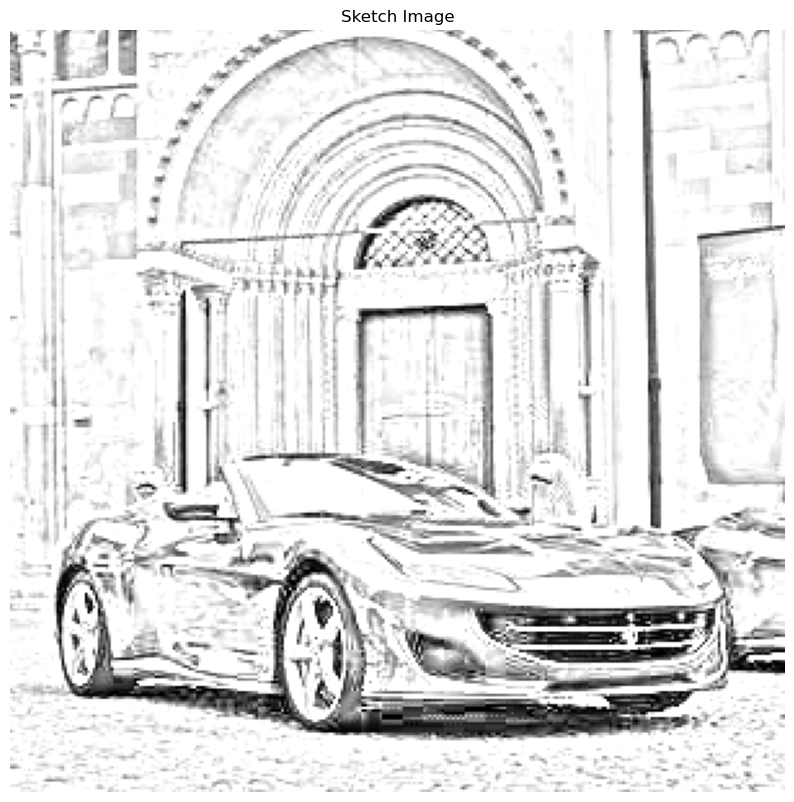

In [41]:
image = cv2.imread(image_address)
sketch = sketch_image(image)
plt.figure(figsize=(10, 10))
plt.imshow(sketch, cmap="gray")
plt.title("Sketch Image")
plt.axis("off")
plt.show()

# Sketching WebCam Video Stream in Real-time


# Visulize fps

In [42]:
def visualize_fps(image, fps: int):
    
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  
    else:
        text_color = (0, 255, 0) 
   
    row_size = 20 
    left_margin = 24 
    font_size = 1
    font_thickness = 2

    fps_text = "FPS = {:.1f}".format(fps)
    text_location = (left_margin, row_size)
    
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    return image


In [44]:
CAMERA_DEVICE_ID = 0 
IMAGE_WIDTH = 800  
IMAGE_HEIGHT = 600  
FRAME_RATE = 30  
DURATION = 1 / FRAME_RATE 

if __name__ == "__main__":
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  

        while cap.isOpened(): 
            start_time = time.time()  
            ret, frame = cap.read()  
            if not ret:
                break  

            frame = sketch_image(frame)  
            end_time = time.time()  
            seconds = end_time - start_time 

            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time
            fps = 1 / seconds

            cv2.imshow("frame", visualize_fps(frame, fps))

            if cv2.waitKey(1) & 0xFF == 27:
                break
    except Exception as e:  
        print(e)  
    finally:
        cv2.destroyAllWindows()  
        cap.release()  

# Sketching a Video in Real-time


In [43]:
Video = os.path.join("videos", "Jobs_1.mp4")  
IMAGE_WIDTH = 1000  
IMAGE_HEIGHT = 600 
fps = 0  
FRAME_RATE = 30 
DURATION = 1 / FRAME_RATE  

if __name__ == "__main__": 
    try:
        cap = cv2.VideoCapture(Video)
        
        while True:  
            start_time = time.time()

            _, frame = cap.read()
            frame = cv2.resize(frame , (IMAGE_WIDTH, IMAGE_HEIGHT)) 
            frame = sketch_image(frame)   

            end_time = time.time() 
            seconds = end_time - start_time
            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time
            fps = 1/seconds

            cv2.imshow("frame", visualize_fps(frame, fps))

            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  
        print(e)  
    finally:
        cv2.destroyAllWindows()  
        cap.release()  